# Custom Failure Modes & Metrics

This notebook shows how to extend MuViS-RB with:

1. A **custom failure mode** by subclassing `SeverityFailure`
2. A **custom metric** by subclassing `Metric`

Both plug directly into the `Testbed` without any other changes.

In [1]:
import numpy as np
import torch
from sklearn.linear_model import LinearRegression

import muvis_c as rob
from muvis_c.failures import SeverityFailure, BiasSeverity
from muvis_c.metrics import Metric

## 1. Define a Custom Failure Mode

Subclass `SeverityFailure` and implement the `apply` method.

Here we create a **Spike Failure** that injects a single spike at the
midpoint of each sequence, with amplitude scaling with severity.

In [2]:
class SpikeSeverity(SeverityFailure):
    """Single spike at the midpoint of the sequence.

    x'[mid] = x[mid] + s * k
    """

    def apply(self, X, feature_idx, severity):
        out = X.clone()
        mid = out.shape[1] // 2
        out[:, mid, feature_idx] += severity * self.k
        return out

# Quick test
X = torch.randn(2, 10, 3)
spike = SpikeSeverity(k=10.0)
X_corr = spike.apply(X, feature_idx=0, severity=1.0)
print(f"Spike diff at midpoint: {(X_corr[:, 5, 0] - X[:, 5, 0]).tolist()}")
print(f"Spike at other points: {(X_corr[:, 3, 0] - X[:, 3, 0]).tolist()}")

Spike diff at midpoint: [10.0, 10.0]
Spike at other points: [0.0, 0.0]


## 2. Define a Custom Metric

Subclass `Metric` and implement `compute(y_true, y_pred) → float`.

Extra metrics are added **alongside** the built-in RMSE — they appear as
additional columns in the raw results DataFrame. The robustness score `R`
is always computed from RMSE.

In [3]:
class MAEMetric(Metric):
    """Mean Absolute Error."""

    name = "mae"

    def compute(self, y_true, y_pred):
        return float(np.mean(np.abs(y_true - y_pred)))

# Quick test
m = MAEMetric()
y = np.array([1.0, 2.0, 3.0])
p = np.array([1.1, 2.3, 2.7])
print(f"MAE: {m.compute(y, p):.4f}")

MAE: 0.2333


## 3. Use Them in a Testbed

In [4]:
np.random.seed(0)
T, C = 15, 4
X_train = np.random.randn(300, T, C).astype(np.float32)
y_train = X_train[:, -1, 0] + 0.3 * X_train.mean(axis=(1, 2)) + 0.05 * np.random.randn(300).astype(np.float32)

X_test = np.random.randn(80, T, C).astype(np.float32)
y_test = X_test[:, -1, 0] + 0.3 * X_test.mean(axis=(1, 2)) + 0.05 * np.random.randn(80).astype(np.float32)

lr = LinearRegression()
lr.fit(X_train.reshape(300, -1), y_train)
print(f"LR train RMSE: {np.sqrt(np.mean((lr.predict(X_train.reshape(300, -1)) - y_train) ** 2)):.4f}")

LR train RMSE: 0.0438


In [5]:
testbed = rob.Testbed(
    dataset=(X_train, y_train, X_test, y_test),
    failures=[SpikeSeverity(k=3.0)],
    severity_steps=5,
    k=3.0,
    seed=42,
    device="cpu",
)

In [6]:
testbed.add_model("LinearRegression", model=lr)
testbed.add_metric(MAEMetric())

In [7]:
results = testbed.run()

Baseline RMSE: 0.8444  Bootstrap: 0.8544
custom | LinearRegression (1/1): 100%|██████████| 24/24 [00:00<00:00, 129.89step/s, SpikeSeverity [1/1] feat 4/4 RMSE=0.061]


In [8]:
results.summary()


────────────────────────────────────────────────────────────────
 Dataset: custom
────────────────────────────────────────────────────────────────
 Model                 Nom. RMSE        mPC      rPC  s_cross
 ──────────────────── ────────── ────────── ──────── ────────
 LinearRegression         0.0546     0.0599    1.098       --



In [9]:
# RMSE is always present; the extra MAE metric adds its own column
results.raw[["failure_mode", "feature_idx", "severity", "rmse", "mae", "boot_mean"]].head(15)

,failure_mode,feature_idx,severity,rmse,mae,boot_mean
0,SpikeSeverity,0,0.0,0.054396,0.043677,0.054581
1,SpikeSeverity,0,0.2,0.056350,0.044634,0.056546
2,SpikeSeverity,0,0.4,0.058750,0.045971,0.058954
3,SpikeSeverity,0,0.6,0.061545,0.048284,0.061754
4,SpikeSeverity,0,0.8,0.064682,0.050875,0.064896
5,SpikeSeverity,0,1.0,0.068115,0.054222,0.068332
6,SpikeSeverity,1,0.0,0.054396,0.043677,0.054581
7,SpikeSeverity,1,0.2,0.056467,0.044685,0.056664
8,SpikeSeverity,1,0.4,0.059030,0.046207,0.059235
9,SpikeSeverity,1,0.6,0.062025,0.048656,0.062235


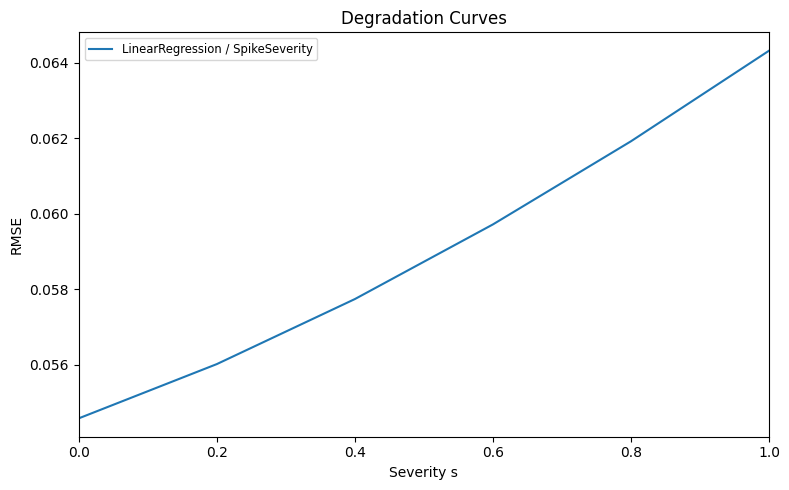

<Axes: title={'center': 'Degradation Curves'}, xlabel='Severity s', ylabel='RMSE'>

In [10]:
results.plot_degradation(show=True)